In [50]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
import time
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
# start browser
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

# open the site
driver.get("https://remoteok.com")

# give the page time to load JS content
time.sleep(5)

# find job rows
jobs = driver.find_elements(By.CSS_SELECTOR, "tr.job")

print(len(jobs))

49


In [32]:
first_job = jobs[1]

title = first_job.find_element(By.CSS_SELECTOR, "h2")

print(title.text)

Senior Software Engineer Ruby on Rails


In [33]:
company = first_job.find_element(By.CSS_SELECTOR, "h3")
print(company.text)

Versapay


In [34]:
time_posted = first_job.find_element(By.CSS_SELECTOR, "time")

print(time_posted.text)

2h


In [35]:
location = first_job.find_element(By.CSS_SELECTOR, ".location")

print(location.text)

Canada (Remote)


In [36]:
skills = first_job.find_elements(By.CSS_SELECTOR, ".tag")

skills_list = [skill.text for skill in skills if skill.text.strip() != ""]

print(skills_list)

['Software', 'SaaS', 'Technical']


In [41]:
all_jobs = []

for job in jobs:
    try:
        title = job.find_element(By.CSS_SELECTOR, "h2").text
    except:
        title = ""
    try:
        company = job.find_element(By.CSS_SELECTOR, "h3").text
    except:
        company = ""
    try:
        location = job.find_element(By.CSS_SELECTOR, ".location").text
    except:
        location = ""
    try:
        time_posted = job.find_element(By.CSS_SELECTOR, "time").text
    except:
        time_posted = ""
    try:
        skills_elements = job.find_elements(By.CSS_SELECTOR, ".tag")
        skills = [s.text for s in skills_elements if s.text.strip() != ""]
    except:
        skills = []

    job_dict = {
        "title": title,
        "company": company,
        "location": location,
        "time_posted": time_posted,
        "skills": skills
    }

    all_jobs.append(job_dict)

# convert to pandas DataFrame
df = pd.DataFrame(all_jobs)

print(df.head())

                                    title                          company  \
0                Senior Frontend Engineer                            Level   
1  Senior Software Engineer Ruby on Rails                         Versapay   
2                  BPM LLP AI ML Engineer                          BPM LLP   
3   Work From Home Client Support Manager  Global Elite Empire Consultants   
4      Senior Software Engineer Karpenter                          Cast AI   

                     location time_posted                             skills  
0                 🌏 Worldwide          9d  [Engineer, Developer, JavaScript]  
1             Canada (Remote)          2h        [Software, SaaS, Technical]  
2              United Kingdom          3h                 [Design, Engineer]  
3  Londonderry, New Hampshire          3h          [Manager, Support, Video]  
4        🌏 Probably worldwide          6h          [Golang, Software, Cloud]  


## TOP SKILLS

In [49]:
from collections import Counter

# flatten all skills into one list
all_skills = [skill for sublist in df['skills'].dropna() for skill in sublist]

# count frequency
skill_counts = Counter(all_skills)

# top 10 most common skills
top_skills = skill_counts.most_common(10)

print(top_skills)

[('Support', 13), ('Design', 12), ('Technical', 10), ('Software', 7), ('Manager', 7), ('Training', 5), ('System', 4), ('Growth', 4), ('Architect', 4), ('Game', 4)]


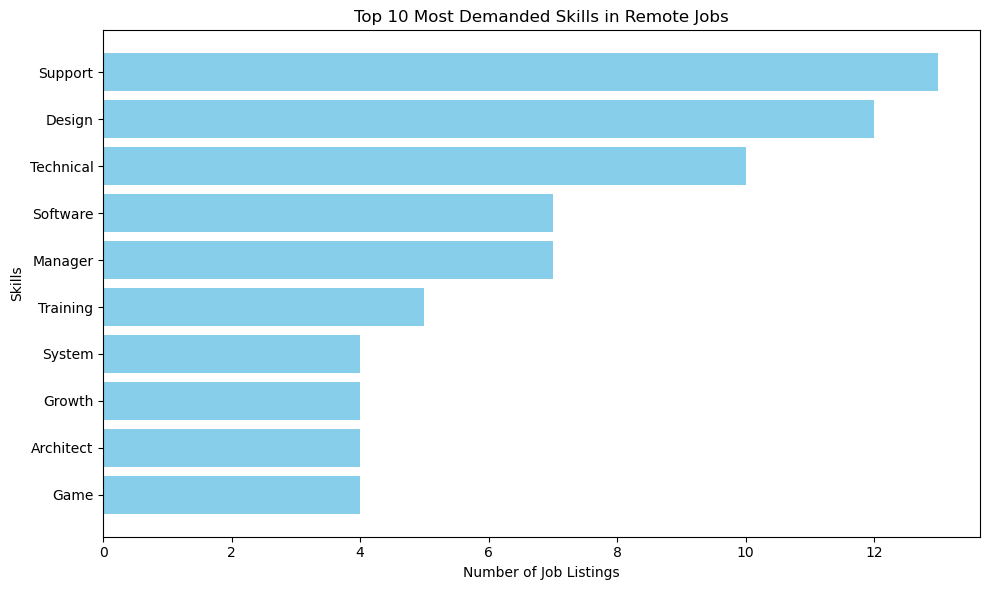

In [51]:
skills, counts = zip(*top_skills)

plt.figure(figsize=(10,6))
plt.barh(skills[::-1], counts[::-1], color='skyblue')  # reverse for descending order
plt.title("Top 10 Most Demanded Skills in Remote Jobs")
plt.xlabel("Number of Job Listings")
plt.ylabel("Skills")
plt.tight_layout()
plt.show()

## Job Titles

In [52]:
# flatten job titles (just the column)
title_counts = Counter(df['title'])

# top 10 most common job titles
top_titles = title_counts.most_common(10)

print(top_titles)

[('Senior Software Engineer', 2), ('Senior Frontend Engineer', 1), ('Senior Software Engineer Ruby on Rails', 1), ('BPM LLP AI ML Engineer', 1), ('Work From Home Client Support Manager', 1), ('Senior Software Engineer Karpenter', 1), ('Senior Software Engineer Reporting', 1), ('CFO', 1), ('Senior Backend Engineer', 1), ('UK Support Specialist', 1)]


In [54]:
# count frequency of each title
title_counts = df['title'].value_counts().reset_index()

# rename columns for clarity
title_counts.columns = ['Job Title', 'Number of Listings']

# show the table
print(title_counts)

                                            Job Title  Number of Listings
0                            Senior Software Engineer                   2
1                            Senior Frontend Engineer                   1
2                                         CHW Manager                   1
3                               Senior Level Designer                   1
4                            Narrative and World Lead                   1
5                     Procurement Specialist Hardware                   1
6                                       Lead Animator                   1
7   Territory Sales Representative Green Grass Sou...                   1
8                    Crypto Market Operations Trainee                   1
9         Customer Service Representative Member Care                   1
10                          Design Intern Summer 2026                   1
11                         Restaurant Account Manager                   1
12                          Journeyper

## top companies

In [56]:
# count how many jobs each company posted
company_counts = df['company'].value_counts()

# check top 10 companies
top_companies = company_counts.head(10)
print(top_companies)

company
Eleventh Hour Games    4
Cast AI                2
Zócalo Health          2
Headspace              1
ezCater, Inc           1
Blueprint              1
Omada Health           1
Trackman A/S           1
Begini                 1
Sidecar Health         1
Name: count, dtype: int64


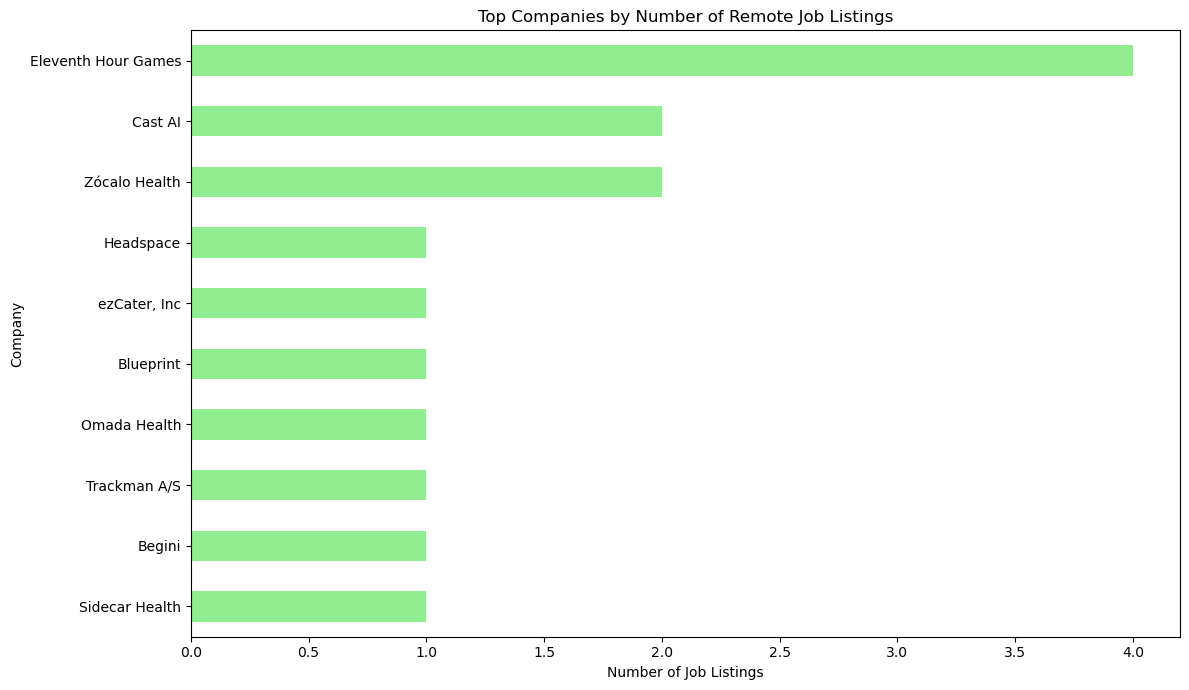

In [58]:
plt.figure(figsize=(12,7))
top_companies.plot(kind='barh', color='lightgreen')
plt.title("Top Companies by Number of Remote Job Listings")
plt.xlabel("Number of Job Listings")
plt.ylabel("Company")
plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

## location

In [66]:
# remove rows where salary says 'Upgrade to Premium'
df = df[df['location'] != "💰 Upgrade to Premium to see salary"].reset_index(drop=True)

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_7980\1205145666.py:14: UserWarning: Glyph 127759 (\N{EARTH GLOBE ASIA-AUSTRALIA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mary-Jane\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127759 (\N{EARTH GLOBE ASIA-AUSTRALIA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


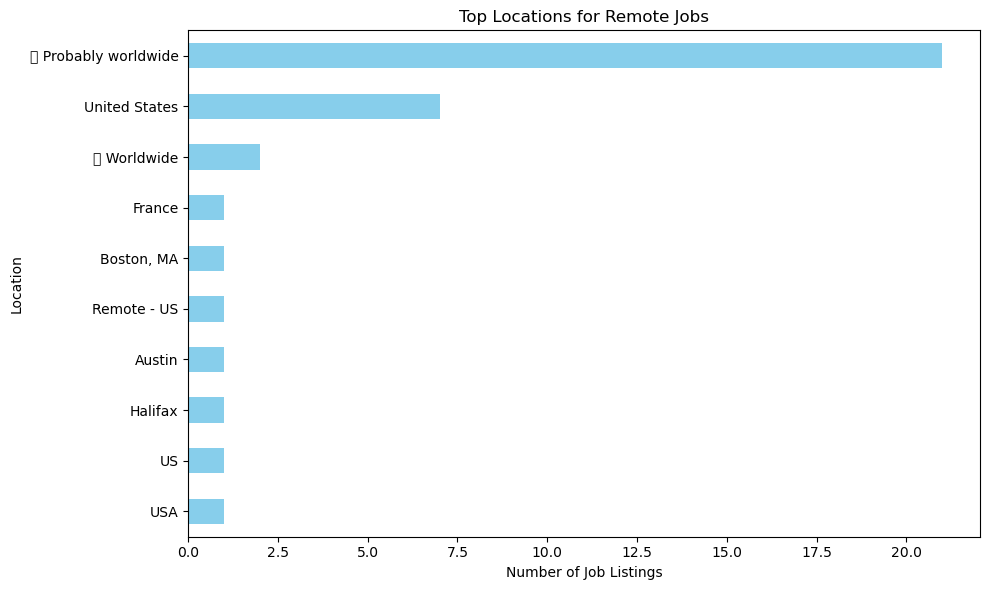

In [67]:
# count jobs per location
location_counts = df['location'].value_counts()

# top 10 locations
top_locations = location_counts.head(10)

# visualize
plt.figure(figsize=(10,6))
top_locations.plot(kind='barh', color='skyblue')
plt.title("Top Locations for Remote Jobs")
plt.xlabel("Number of Job Listings")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## job posting frequency

In [68]:
import re

def time_to_hours(text):
    days = hours = 0
    if 'd' in text:
        match = re.search(r'(\d+)d', text)
        if match:
            days = int(match.group(1))
    if 'h' in text:
        match = re.search(r'(\d+)h', text)
        if match:
            hours = int(match.group(1))
    return days*24 + hours

df['hours_ago'] = df['time_posted'].apply(time_to_hours)

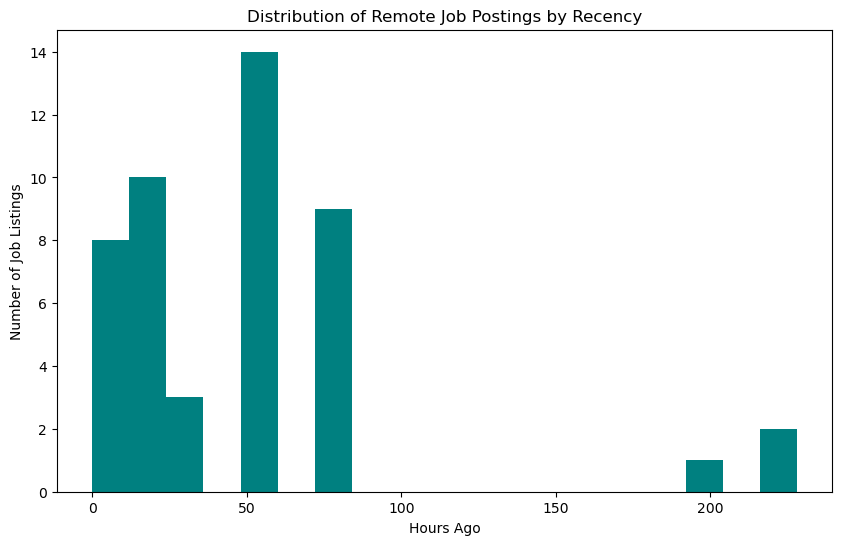

In [69]:
plt.figure(figsize=(10,6))
plt.hist(df['hours_ago'], bins=range(0, 240, 12), color='teal')  # bins every 12 hours
plt.title("Distribution of Remote Job Postings by Recency")
plt.xlabel("Hours Ago")
plt.ylabel("Number of Job Listings")
plt.show()